In [3]:
import os
os.chdir('/ihome/cmpinf0010-sec1010_2026s/rsa57/cmpinf-0010-FinalProj')


"""
Cost score planning
 1: Normalize the data
Formula: (value - min) / (max - min)

 2: Flip the data
Formula: flipped = 1 - normalized_value

 3:
Median Home Value (2010)           = weight 0.30
Median Sale Price (2010)           = weight 0.25
Home Value to Income Ratio         = weight 0.20  (proxy for rent burden - home value divided by median income)
Commute to Work: Drive Alone       = weight 0.15  (proxy for transportation cost)
Est. Percent Under Poverty (2010)  = weight 0.10  (proxy for unemployment - no unemployment column available)

 4:
Highest score = most affordable
df.sort_values('cost_of_living_score', ascending=False)
"""

import pandas as pd

# Load the files
housing = pd.read_csv("housing.csv")
education_income = pd.read_csv("education-income.csv")
transportation = pd.read_csv("transportation.csv")
employment = pd.read_csv("employment.csv")

# Drop duplicate columns from each file before merging, keeping them only in housing
cols_to_drop = ["Sector #", "Population (2010)"]
education_income = education_income.drop(columns=cols_to_drop)
transportation = transportation.drop(columns=cols_to_drop)
employment = employment.drop(columns=cols_to_drop)

# Merge all files on neighborhood column
df = housing.merge(education_income, on="Neighborhood")
df = df.merge(transportation, on="Neighborhood")
df = df.merge(employment, on="Neighborhood")

# Get rid of the stupid ass formatting
dollar_cols = [
    "Median Home  Value (2010)",
    "Median Sale Price (2010)",
    "2009 Median Income ('09 Dollars)",
]
percent_cols = [
    "Commute to Work: Drive Alone (2010)",
    "Est. Percent Under Poverty (2010)",
]

for col in dollar_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in percent_cols:
    df[col] = df[col].astype(str).str.replace("%", "", regex=False).str.strip()
    df[col] = pd.to_numeric(df[col], errors="coerce")


manual_sale_prices = {
    "Allegheny Center": 125000,
    "Arlington Heights": 100000,
    "Glen Hazel": 114350,
    "North Shore": 111755,
    "South Shore": 125000,
    "Northview Heights": 130000,
}

for neighborhood, price in manual_sale_prices.items():
    df.loc[df["Neighborhood"] == neighborhood, "Median Sale Price (2010)"] = price

# Create a home value to income ratio as a proxy for housing burden
df["home_value_to_income"] = (
    df["Median Home  Value (2010)"] / df["2009 Median Income ('09 Dollars)"]
)

# Normalize the data
df["home_value_normalized"] = (
    df["Median Home  Value (2010)"] - df["Median Home  Value (2010)"].min()
) / (df["Median Home  Value (2010)"].max() - df["Median Home  Value (2010)"].min())
df["sale_price_normalized"] = (
    df["Median Sale Price (2010)"] - df["Median Sale Price (2010)"].min()
) / (df["Median Sale Price (2010)"].max() - df["Median Sale Price (2010)"].min())
df["burden_normalized"] = (
    df["home_value_to_income"] - df["home_value_to_income"].min()
) / (df["home_value_to_income"].max() - df["home_value_to_income"].min())
df["transport_normalized"] = (
    df["Commute to Work: Drive Alone (2010)"]
    - df["Commute to Work: Drive Alone (2010)"].min()
) / (
    df["Commute to Work: Drive Alone (2010)"].max()
    - df["Commute to Work: Drive Alone (2010)"].min()
)
df["poverty_normalized"] = (
    df["Est. Percent Under Poverty (2010)"]
    - df["Est. Percent Under Poverty (2010)"].min()
) / (
    df["Est. Percent Under Poverty (2010)"].max()
    - df["Est. Percent Under Poverty (2010)"].min()
)

# Flip the data, lower cost means higher score
df["home_value_score"] = 1 - df["home_value_normalized"]
df["sale_price_score"] = 1 - df["sale_price_normalized"]
df["burden_score"] = 1 - df["burden_normalized"]
df["transportation_score"] = 1 - df["transport_normalized"]
df["poverty_score"] = 1 - df["poverty_normalized"]

# Apply weighting and sum into a single score
df["cost_of_living_score"] = (
    df["home_value_score"] * 0.30
    + df["sale_price_score"] * 0.25
    + df["burden_score"] * 0.20
    + df["transportation_score"] * 0.15
    + df["poverty_score"] * 0.10
)

# Sort and display results

cols_used = [
    "Median Home  Value (2010)",
    "Median Sale Price (2010)",
    "2009 Median Income ('09 Dollars)",
    "Commute to Work: Drive Alone (2010)",
    "Est. Percent Under Poverty (2010)",
]


"""
Allegheny Center: Median sale price: ~125,000
Arlington Heights: Median sale price: ~100,000
Glen Hazel: Median sale price: 83,700-145,000
North Shore: 111,755
South Shore: ~125,000
Northview Hieghts: 130,000
Chateau: Not in the running due to sparse population and missing data


"""

# print("\nMissing data breakdown:")
# print(
#     df[df["cost_of_living_score"].isna()][["Neighborhood"] + cols_used].to_string(
#         index=False
#     )
# )


results = (
    df[["Neighborhood", "cost_of_living_score"]]
    .dropna()
    .sort_values("cost_of_living_score", ascending=False)
)

print(results)


           Neighborhood  cost_of_living_score
86             West End              0.916015
8           Beltzhoover              0.891047
73        Spring Garden              0.888034
44              Larimer              0.877020
42        Homewood West              0.871601
..                  ...                   ...
55        North Oakland              0.480397
33           Friendship              0.479234
62         Point Breeze              0.469806
67            Shadyside              0.382872
75  Squirrel Hill North              0.291476

[85 rows x 2 columns]


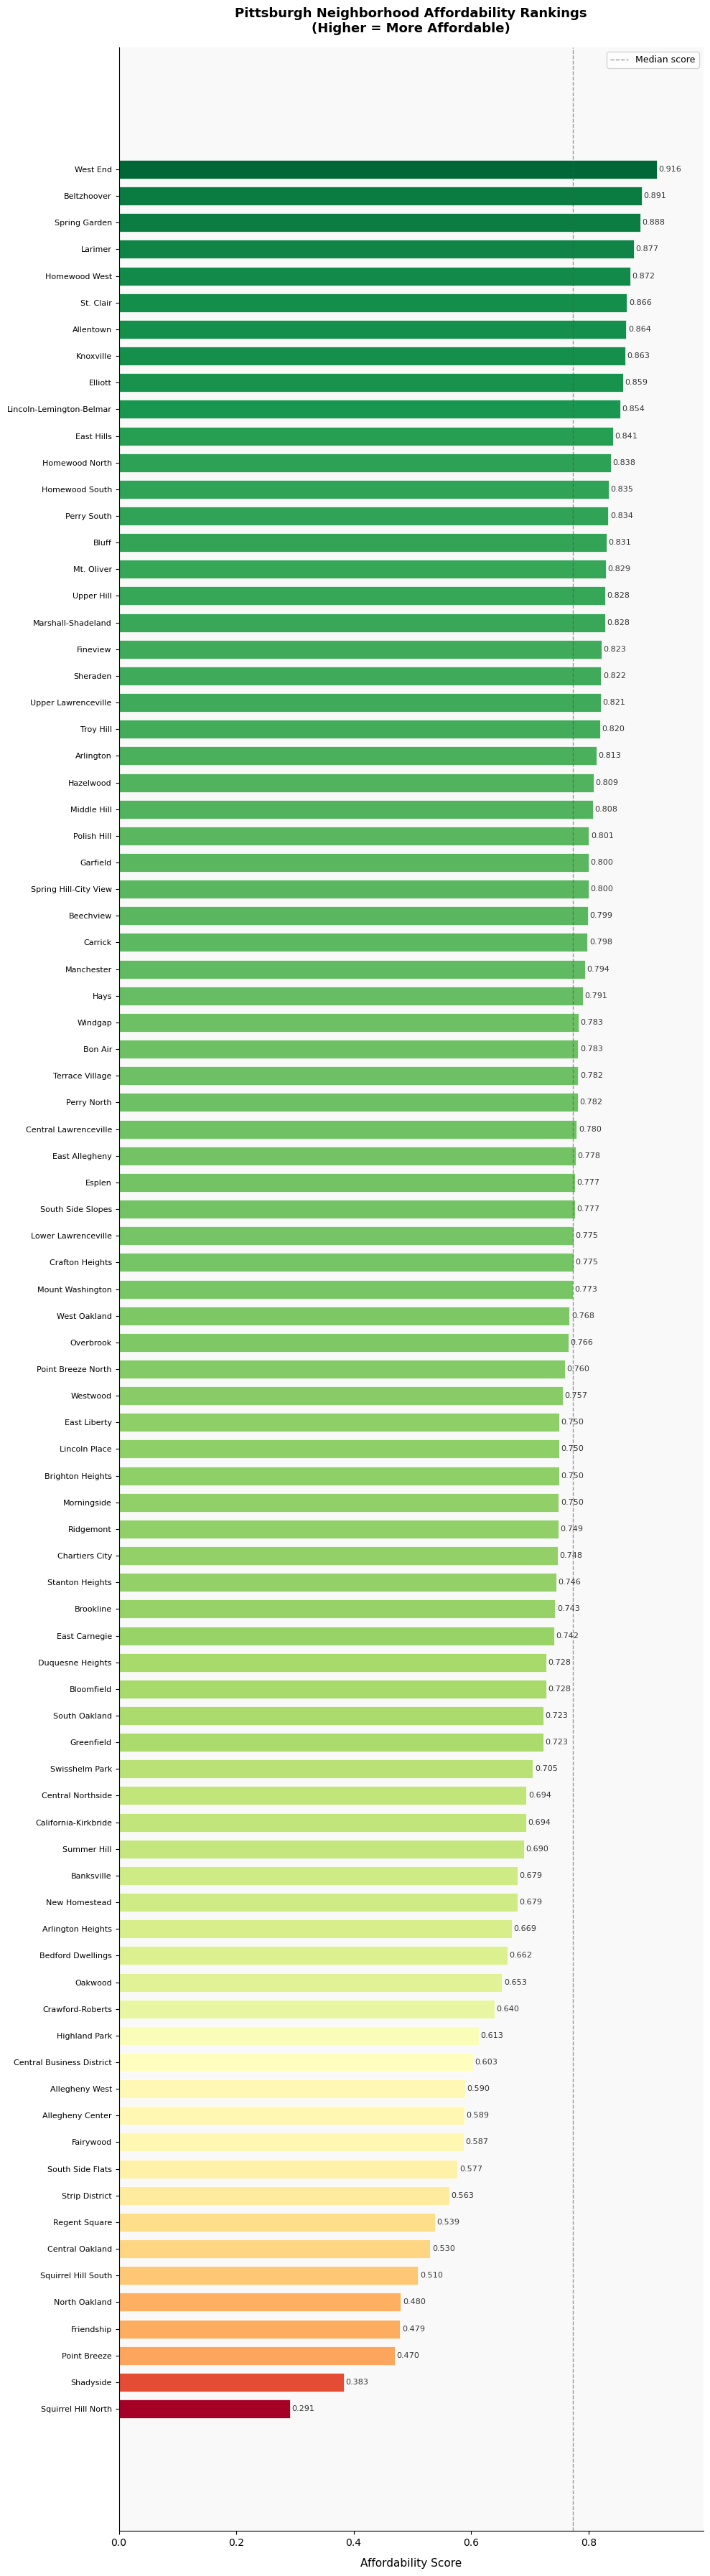

Chart saved as affordability_rankings.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# drop NaN and sort
chart_data = (
    df[["Neighborhood", "cost_of_living_score"]]
    .dropna()
    .sort_values("cost_of_living_score", ascending=True)
)

# Color gradient: low score = red, high score = green
norm = mcolors.Normalize(vmin=chart_data["cost_of_living_score"].min(),
                         vmax=chart_data["cost_of_living_score"].max())
colors = plt.cm.RdYlGn(norm(chart_data["cost_of_living_score"].values))

# Build chart
fig, ax = plt.subplots(figsize=(10, len(chart_data) * 0.4 + 2))

bars = ax.barh(
    chart_data["Neighborhood"],
    chart_data["cost_of_living_score"],
    color=colors,
    edgecolor="white",
    linewidth=0.5,
    height=0.7,
)

# Add score labels at the end of each bar
for bar, val in zip(bars, chart_data["cost_of_living_score"]):
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left",
        fontsize=8,
        color="#333333",
    )

# Styling
ax.set_xlabel("Affordability Score", fontsize=11, labelpad=10)
ax.set_title("Pittsburgh Neighborhood Affordability Rankings\n(Higher = More Affordable)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlim(0, chart_data["cost_of_living_score"].max() + 0.08)
ax.axvline(x=chart_data["cost_of_living_score"].median(), color="#555", 
           linestyle="--", linewidth=1, alpha=0.6, label="Median score")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=8)
ax.set_facecolor("#f9f9f9")
fig.patch.set_facecolor("#ffffff")

plt.tight_layout()
plt.savefig("affordability_rankings.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved as affordability_rankings.png")